In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from LSAS.LSAS import alg_LSAS

rng = np.random.default_rng(12345)

## Figure 3

In [4]:
nodes_fig3 = ["V1", "V6", "V7", "U1", "U2", "V2", "V3", "X", "V4", "V5", "Y"]

treatment_fig3 = 'X'
outcome_fig3 = 'Y'

latent_nodes = ["U1", "U2"]
observed_nodes = [n for n in nodes_fig3 if n not in latent_nodes]

B = pd.DataFrame(0, index=nodes_fig3, columns=nodes_fig3, dtype=float)

B.loc['V1', 'V2'] = rng.uniform(0.5, 1.5)
B.loc['V1', 'Y'] = rng.uniform(0.5, 1.5)
B.loc['V1', 'X'] = rng.uniform(0.5, 1.5)
B.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
B.loc['V2', 'X'] = rng.uniform(0.5, 1.5)
B.loc['V6', 'X'] = rng.uniform(0.5, 1.5)
B.loc['V6', 'V7'] = rng.uniform(0.5, 1.5)
B.loc['V4', 'Y'] = rng.uniform(0.5, 1.5)
B.loc['V4', 'V5'] = rng.uniform(0.5, 1.5)
B.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
B.loc['U1', 'V3'] = rng.uniform(0.5, 1.5)
B.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
B.loc['U2', 'V3'] = rng.uniform(0.5, 1.5)
B.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)

B

,V1,V6,V7,U1,U2,V2,V3,X,V4,V5,Y
V1,0.0,0.0,0.000000,0.0,0.0,0.727336,0.000000,1.297365,0.0,0.000000,0.816758
V6,0.0,0.0,1.098309,0.0,0.0,0.000000,0.000000,0.832814,0.0,0.000000,0.000000
V7,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
U1,0.0,0.0,0.000000,0.0,0.0,0.000000,0.748246,1.448881,0.0,0.000000,0.000000
U2,0.0,0.0,0.000000,0.0,0.0,0.000000,1.167237,0.000000,0.0,0.000000,0.595898
V2,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.891110,0.0,0.000000,1.176255
V3,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
X,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,1.441803
V4,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.172756,0.686734
V5,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000


In [5]:
sample_sizes = [1000, 5000, 10000, 15000]
n_reps = 100

results_fig3 = []
structure_name = 'figure3'

for n in sample_sizes:
    for rep in range(n_reps):
        B = pd.DataFrame(0, index=nodes_fig3, columns=nodes_fig3, dtype=float)

        B.loc['V1', 'V2'] = rng.uniform(0.5, 1.5)
        B.loc['V1', 'Y'] = rng.uniform(0.5, 1.5)
        B.loc['V1', 'X'] = rng.uniform(0.5, 1.5)
        B.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
        B.loc['V2', 'X'] = rng.uniform(0.5, 1.5)
        B.loc['V6', 'X'] = rng.uniform(0.5, 1.5)
        B.loc['V6', 'V7'] = rng.uniform(0.5, 1.5)
        B.loc['V4', 'Y'] = rng.uniform(0.5, 1.5)
        B.loc['V4', 'V5'] = rng.uniform(0.5, 1.5)
        B.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
        B.loc['U1', 'V3'] = rng.uniform(0.5, 1.5)
        B.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
        B.loc['U2', 'V3'] = rng.uniform(0.5, 1.5)
        B.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)

        E = pd.DataFrame(rng.normal(0, 1, size=(n, len(nodes_fig3))), columns=nodes_fig3)

        D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig3, dtype=float)

        for node in nodes_fig3:
            parents = B.index[B[node] != 0].tolist()
            if len(parents) == 0:
                D_full[node] = E[node].values
            else:
                D_full[node] = D_full[parents].values @ B.loc[parents, node].values + E[node].values

        # remove latent variables
        D_obs = D_full[observed_nodes].copy()

        B_np = B.loc[nodes_fig3, nodes_fig3].values
        I = np.eye(len(nodes_fig3))
        total_effect_matrix = np.linalg.inv(I - B_np) - I

        x_idx = nodes_fig3.index('X')
        y_idx = nodes_fig3.index('Y')

        true_ce = total_effect_matrix[x_idx, y_idx]

        result = alg_LSAS(D_obs, treatment_fig3, outcome_fig3)

        VASs = result["VASs"]
        estimated_ce = result["ATE"]
        nTest = result["CI_num"]
    

        if estimated_ce is None:
            results_fig3.append({
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_ce": true_ce,
                "estimated_ce": np.nan,
                "RE": np.nan,
                "nTest": nTest,
                "VASs": str(VASs)
            })
            continue

        RE = abs((estimated_ce - true_ce) / true_ce) * 100

        results_fig3.append({
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "true_ce": true_ce,
            "estimated_ce": estimated_ce,
            "RE": RE,
            "nTest": nTest,
            "VASs": str(VASs)
        })


results_fig3 = pd.DataFrame(results_fig3)
results_fig3.head()

,structure,sample_size,rep,true_ce,estimated_ce,RE,nTest,VASs
0,figure3,1000,0,0.965193,1.004900,4.113856,66,"[{'VAS': ['V1', 'V2']}, {'VAS': ['V1', 'V3']},..."
1,figure3,1000,1,1.059923,1.045115,1.397091,72,"[{'VAS': ['V1', 'V2']}, {'VAS': ['V1', 'V2', '..."
2,figure3,1000,2,0.836063,0.892055,6.697070,124,"[{'VAS': ['V2']}, {'VAS': ['V1', 'V2']}, {'VAS..."
3,figure3,1000,3,0.597874,0.560070,6.323063,46,"[{'VAS': ['V1', 'V2']}, {'VAS': ['V1', 'V2', '..."
4,figure3,1000,4,1.102486,1.099690,0.253633,70,"[{'VAS': ['V1', 'V2']}, {'VAS': ['V1', 'V2', '..."


In [6]:
summary_fig3 = (
    results_fig3
    .groupby("sample_size", as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary_fig3

,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,1000,7.049926,9.125502,76.00,21.459381
1,5000,5.894761,11.401982,114.95,32.522059
2,10000,4.964268,10.795415,137.53,30.896195
3,15000,2.979229,7.225979,134.44,27.027229


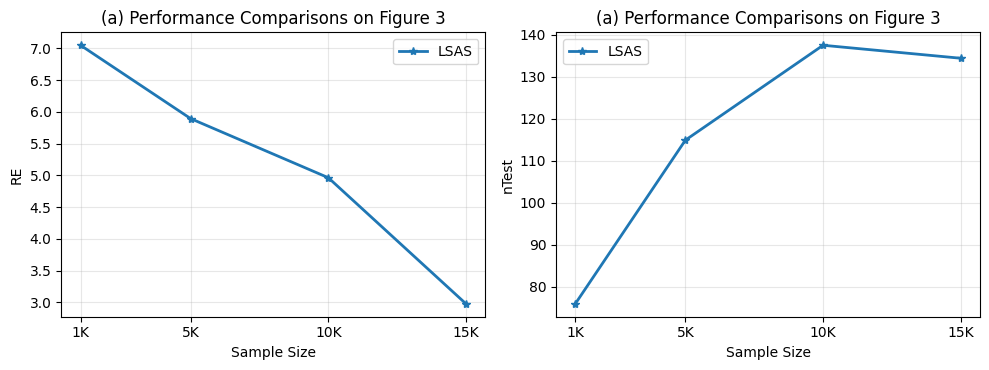

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# RE panel
axes[0].plot(summary_fig3["sample_size"], summary_fig3["mean_RE"], marker="*", linewidth=2, label="LSAS")
axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) Performance Comparisons on Figure 3")
axes[0].set_xticks(sample_sizes)
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()


axes[1].plot(summary_fig3["sample_size"], summary_fig3["mean_nTest"], marker="*", linewidth=2, label="LSAS")
axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(a) Performance Comparisons on Figure 3")
axes[1].set_xticks(sample_sizes)
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Figure 4

In [8]:
nodes_fig4 = [
    "U1", "U2", "U3", "U4",
    "V4", "V7", "V9",
    "V5", "V6", "V2",
    "X", "V8", "V1",
    "Y", "V3"
]

treatment_fig4 = 'X'
outcome_fig4 = 'Y'

latent_nodes = ["U1", "U2", "U3", "U4"]
observed_nodes = [n for n in nodes_fig4 if n not in latent_nodes]

B_fig4 = pd.DataFrame(0, index=nodes_fig4, columns=nodes_fig4, dtype=float)

B_fig4.loc['U4', 'V5'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U4', 'V6'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V7', 'V6'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V6', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V5', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U3', 'V5'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U3', 'X'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V2', 'V3'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V9', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V9', 'V8'] = rng.uniform(0.5, 1.5)
B_fig4.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U1', 'V1'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U2', 'V1'] = rng.uniform(0.5, 1.5)
B_fig4.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V8', 'X'] = rng.uniform(0.5, 1.5)
B_fig4.loc['V8', 'Y'] = rng.uniform(0.5, 1.5)

B_fig4

,U1,U2,U3,U4,V4,V7,V9,V5,V6,V2,X,V8,V1,Y,V3
U1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.952479,0.000000,1.078311,0.000000,0.000000
U2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,1.171377,0.781700,0.000000
U3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.716333,0.000000,0.0,0.581295,0.000000,0.000000,0.000000,0.000000
U4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.811475,1.118005,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
V4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
V7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.883497,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
V9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,1.056652,0.000000,0.795722,0.000000
V5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.892734,0.000000
V6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.817938,0.000000
V2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.542538,1.263718


In [9]:
sample_sizes = [1000, 5000, 10000, 15000]
n_reps = 100

results_fig4 = []
structure_name = 'figure4'

for n in sample_sizes:
    for rep in range(n_reps):
        B_fig4 = pd.DataFrame(0, index=nodes_fig4, columns=nodes_fig4, dtype=float)

        B_fig4.loc['U4', 'V5'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U4', 'V6'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V7', 'V6'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V6', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V5', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U3', 'V5'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U3', 'X'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V2', 'V3'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V2', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V9', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V9', 'V8'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['X', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U1', 'V1'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U1', 'X'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U2', 'V1'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['U2', 'Y'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V8', 'X'] = rng.uniform(0.5, 1.5)
        B_fig4.loc['V8', 'Y'] = rng.uniform(0.5, 1.5)

        E = pd.DataFrame(rng.normal(0, 1, size=(n, len(nodes_fig4))), columns=nodes_fig4)

        D_full = pd.DataFrame(0, index=np.arange(n), columns=nodes_fig4, dtype=float)

        for node in nodes_fig4:
            parents = B_fig4.index[B_fig4[node] != 0].tolist()
            if len(parents) == 0:
                D_full[node] = E[node].values
            else:
                D_full[node] = D_full[parents].values @ B_fig4.loc[parents, node].values + E[node].values

        # remove latent variables
        D_obs = D_full[observed_nodes].copy()

        B_np = B_fig4.loc[nodes_fig4, nodes_fig4].values
        I = np.eye(len(nodes_fig4))
        total_effect_matrix = np.linalg.inv(I - B_np) - I

        x_idx = nodes_fig4.index('X')
        y_idx = nodes_fig4.index('Y')

        true_ce = total_effect_matrix[x_idx, y_idx]

        result = alg_LSAS(D_obs, treatment_fig4, outcome_fig4)

        VASs = result["VASs"]
        estimated_ce = result["ATE"]
        nTest = result["CI_num"]
    

        if estimated_ce is None:
            results_fig4.append({
                "structure": structure_name,
                "sample_size": n,
                "rep": rep,
                "true_ce": true_ce,
                "estimated_ce": np.nan,
                "RE": np.nan,
                "nTest": nTest,
                "VASs": str(VASs)
            })
            continue

        RE = abs((estimated_ce - true_ce) / true_ce) * 100

        results_fig4.append({
            "structure": structure_name,
            "sample_size": n,
            "rep": rep,
            "true_ce": true_ce,
            "estimated_ce": estimated_ce,
            "RE": RE,
            "nTest": nTest,
            "VASs": str(VASs)
        })


results_fig4 = pd.DataFrame(results_fig4)
results_fig4.head()

,structure,sample_size,rep,true_ce,estimated_ce,RE,nTest,VASs
0,figure4,1000,0,0.548051,NaN,NaN,553,None
1,figure4,1000,1,0.830818,NaN,NaN,553,None
2,figure4,1000,2,1.242348,1.676029,34.908227,392,"[{'VAS': ['V9']}, {'VAS': ['V2']}, {'VAS': ['V..."
3,figure4,1000,3,0.834410,0.674921,19.113996,440,"[{'VAS': ['V9', 'V5', 'V6', 'V2', 'V1']}, {'VA..."
4,figure4,1000,4,0.695898,0.911567,30.991566,392,"[{'VAS': ['V9']}, {'VAS': ['V6']}, {'VAS': ['V..."


In [10]:
summary_fig4 = (
    results_fig4
    .groupby("sample_size", as_index=False)
    .agg(
        mean_RE=("RE", "mean"),
        std_RE=("RE", "std"),
        mean_nTest=("nTest", "mean"),
        std_nTest=("nTest", "std"),
    )
)

summary_fig4

,sample_size,mean_RE,std_RE,mean_nTest,std_nTest
0,1000,36.411678,21.301982,519.53,101.772320
1,5000,13.722808,13.539126,556.07,102.223883
2,10000,8.303932,5.708104,545.92,99.203971
3,15000,7.755564,6.756859,521.35,95.188847


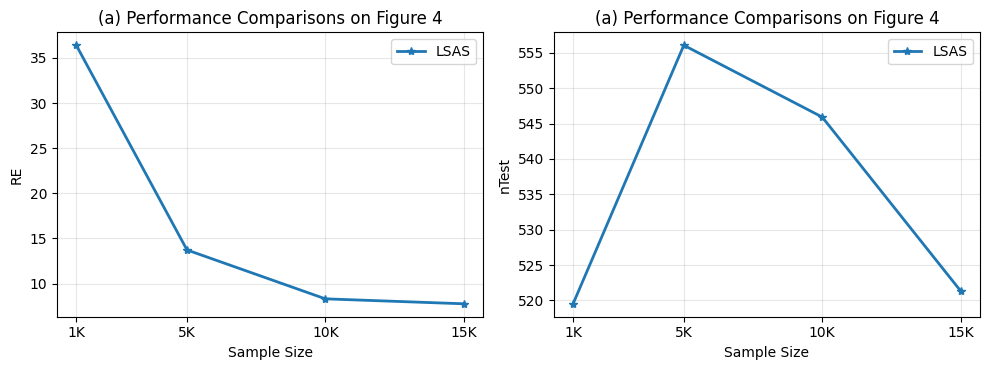

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

# RE panel
axes[0].plot(summary_fig4["sample_size"], summary_fig4["mean_RE"], marker="*", linewidth=2, label="LSAS")
axes[0].set_xlabel("Sample Size")
axes[0].set_ylabel("RE")
axes[0].set_title("(a) Performance Comparisons on Figure 4")
axes[0].set_xticks(sample_sizes)
axes[0].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[0].grid(alpha=0.3)
axes[0].legend()

# nTest panel
axes[1].plot(summary_fig4["sample_size"], summary_fig4["mean_nTest"], marker="*", linewidth=2, label="LSAS")
axes[1].set_xlabel("Sample Size")
axes[1].set_ylabel("nTest")
axes[1].set_title("(a) Performance Comparisons on Figure 4")
axes[1].set_xticks(sample_sizes)
axes[1].set_xticklabels(["1K", "5K", "10K", "15K"])
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()